In [1]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [2]:
Project_6_EDA

NameError: name 'Project_6_EDA' is not defined

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print("Shape:", df.shape)
display(df.head())

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("===== DATA QUALITY AUDIT =====")

print("\n1. Dataset Shape:")
print(df.shape)

print("\n2. Column Names:")
print(df.columns.tolist())

print("\n3. Data Types:")
print(df.dtypes)

print("\n4. Missing Values:")
print(df.isnull().sum())

print("\n5. Duplicate Rows:")
print(df.duplicated().sum())

print("\n6. Unique Values:")
print(df.nunique())

print("\n7. Numeric Summary:")
display(df.describe())

===== DATA QUALITY AUDIT =====

1. Dataset Shape:
(9994, 21)

2. Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

3. Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

4. Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode 

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# Create a working copy
df_clean = df.copy()

# Convert date columns
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

# Create time-based columns
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Quarter"] = "Q" + df_clean["Order Date"].dt.quarter.astype(str)

# Calculate profit margin
df_clean["Profit Margin"] = (
    df_clean["Profit"] / df_clean["Sales"]
) * 100

# Calculate shipping days
df_clean["Shipping Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nNew columns:")
print(df_clean.columns.tolist())

print("\nDate types:")
print(df_clean[["Order Date", "Ship Date"]].dtypes)

display(df_clean.head())

Original shape: (9994, 21)
Cleaned shape: (9994, 27)

New columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name', 'Quarter', 'Profit Margin', 'Shipping Days']

Date types:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Profit Margin,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,Q4,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,Q4,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,Q2,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,Q4,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,Q4,11.25,7


In [6]:
# PROJECT 6 — EDA #1: Overall Business KPIs

total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()

overall_margin = (total_profit / total_sales) * 100

print("===== OVERALL BUSINESS KPIs =====")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {overall_margin:.2f}%")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

===== OVERALL BUSINESS KPIs =====
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Quantity Sold: 37,873
Total Orders: 5,009
Total Customers: 793


In [7]:
# PROJECT 6 — EDA #2: Category Performance

category_performance = (
    df_clean.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

category_performance["Profit Margin"] = (
    category_performance["Profit"]
    / category_performance["Sales"]
) * 100

category_performance = category_performance.sort_values(
    "Sales", ascending=False
)

display(category_performance)

,Category,Sales,Profit,Quantity,Orders,Profit Margin
2,Technology,836154.0330,145454.9481,6939,1544,17.395712
0,Furniture,741999.7953,18451.2728,8028,1764,2.486695
1,Office Supplies,719047.0320,122490.8008,22906,3742,17.035158


In [8]:
# PROJECT 6 — EDA #3: Sub-Category Profitability

subcategory_performance = (
    df_clean.groupby(["Category", "Sub-Category"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

subcategory_performance["Profit Margin"] = (
    subcategory_performance["Profit"]
    / subcategory_performance["Sales"]
) * 100

subcategory_performance = subcategory_performance.sort_values(
    "Profit", ascending=True
)

display(subcategory_performance)

,Category,Sub-Category,Sales,Profit,Quantity,Orders,Profit Margin
3,Furniture,Tables,206965.5320,-17725.4811,1241,307,-8.564460
0,Furniture,Bookcases,114879.9963,-3472.5560,868,224,-3.022768
12,Office Supplies,Supplies,46673.5380,-1189.0995,647,187,-2.547695
8,Office Supplies,Fasteners,3024.2800,949.5182,914,215,31.396504
15,Technology,Machines,189238.6310,3384.7569,440,112,1.788618
9,Office Supplies,Labels,12486.3120,5546.2540,1400,346,44.418672
5,Office Supplies,Art,27118.7920,6527.7870,3000,731,24.071083
7,Office Supplies,Envelopes,16476.4020,6964.1767,906,249,42.267582
2,Furniture,Furnishings,91705.1640,13059.1436,3563,877,14.240358
4,Office Supplies,Appliances,107532.1610,18138.0054,1729,451,16.867517


In [9]:
# PROJECT 6 — EDA #4: Discount vs Profitability

discount_analysis = (
    df_clean.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"]
    / discount_analysis["Sales"]
) * 100

display(discount_analysis)

,Discount,Sales,Profit,Orders,Quantity,Profit Margin
0,0.00,1.087908e+06,320987.6032,2644,18267,29.505019
1,0.10,5.436935e+04,9029.1770,89,373,16.607108
2,0.15,2.755852e+04,1418.9915,51,198,5.149012
3,0.20,7.645944e+05,90337.3060,2407,13660,11.815063
4,0.30,1.032267e+05,-10369.2774,211,849,-10.045155
5,0.32,1.449346e+04,-2391.1377,27,105,-16.498047
6,0.40,1.164178e+05,-23057.0504,185,786,-19.805437
7,0.45,5.484974e+03,-2493.1111,10,45,-45.453472
8,0.50,5.891854e+04,-20506.4281,64,241,-34.804712
9,0.60,6.644700e+03,-5944.6552,127,501,-89.464614


In [10]:
# PROJECT 6 — EDA #5: Discount by Category

discount_category = (
    df_clean.groupby(["Category", "Discount"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

discount_category["Profit Margin"] = (
    discount_category["Profit"]
    / discount_category["Sales"]
) * 100

display(
    discount_category.sort_values(
        ["Category", "Discount"]
    )
)

,Category,Discount,Sales,Profit,Orders,Profit Margin
0,Furniture,0.00,256025.2700,58133.0764,739,22.705992
1,Furniture,0.10,46634.2470,7111.0119,71,15.248476
2,Furniture,0.15,27558.5215,1418.9915,51,5.149012
3,Furniture,0.20,216631.0160,6265.9491,539,2.892452
4,Furniture,0.30,99470.3500,-10695.3169,207,-10.752266
5,Furniture,0.32,14493.4588,-2391.1377,27,-16.498047
6,Furniture,0.40,45614.4060,-16187.3968,72,-35.487466
7,Furniture,0.45,5484.9740,-2493.1111,10,-45.453472
8,Furniture,0.50,20983.4700,-12871.1990,53,-61.339707
9,Furniture,0.60,6644.7000,-5944.6552,127,-89.464614


In [11]:
# PROJECT 6 — EDA #6: Loss-Making Furniture Analysis

furniture_loss = (
    df_clean[
        df_clean["Sub-Category"].isin(["Tables", "Bookcases"])
    ]
    .groupby(["Sub-Category", "Discount"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

furniture_loss["Profit Margin"] = (
    furniture_loss["Profit"]
    / furniture_loss["Sales"]
) * 100

display(
    furniture_loss.sort_values(
        ["Sub-Category", "Discount"]
    )
)

,Sub-Category,Discount,Sales,Profit,Orders,Quantity,Profit Margin
0,Bookcases,0.00,31935.9800,6075.7117,60,211,19.024660
1,Bookcases,0.15,27558.5215,1418.9915,51,198,5.149012
2,Bookcases,0.20,26841.4960,130.5022,44,167,0.486196
3,Bookcases,0.30,4282.6980,-555.8726,9,43,-12.979496
4,Bookcases,0.32,14493.4588,-2391.1377,27,105,-16.498047
5,Bookcases,0.50,7308.4600,-4255.8117,18,76,-58.231306
6,Bookcases,0.70,2459.3820,-3894.9394,15,68,-158.370656
7,Tables,0.00,71578.7600,13276.2997,70,310,18.547820
8,Tables,0.20,45430.2320,-303.5580,69,281,-0.668185
9,Tables,0.30,25182.1500,-3402.3276,51,180,-13.510870


In [12]:
# PROJECT 6 — EDA #7: Regional Performance

regional_performance = (
    df_clean.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

regional_performance["Profit Margin"] = (
    regional_performance["Profit"]
    / regional_performance["Sales"]
) * 100

regional_performance = regional_performance.sort_values(
    "Sales", ascending=False
)

display(regional_performance)

,Region,Sales,Profit,Quantity,Orders,Customers,Profit Margin
3,West,725457.8245,108418.4489,12266,1611,686,14.944831
1,East,678781.2400,91522.7800,10618,1401,674,13.483399
0,Central,501239.8908,39706.3625,8780,1175,629,7.921629
2,South,391721.9050,46749.4303,6209,822,512,11.934342


In [13]:
# PROJECT 6 — EDA #8: Region × Category Profitability

region_category = (
    df_clean.groupby(["Region", "Category"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

region_category["Profit Margin"] = (
    region_category["Profit"]
    / region_category["Sales"]
) * 100

display(
    region_category.sort_values(
        ["Region", "Profit Margin"]
    )
)

,Region,Category,Sales,Profit,Orders,Profit Margin
0,Central,Furniture,163797.1638,-2871.0494,403,-1.752808
1,Central,Office Supplies,167026.4150,8879.9799,880,5.316512
2,Central,Technology,170416.3120,33697.4320,356,19.773595
3,East,Furniture,208291.2040,3046.1658,488,1.462455
5,East,Technology,264973.9810,47462.0351,443,17.911961
4,East,Office Supplies,205516.0550,41014.5791,1074,19.956873
6,South,Furniture,117298.6840,6771.2061,278,5.772619
8,South,Technology,148771.9080,19991.8314,255,13.437908
7,South,Office Supplies,125651.3130,19986.3928,619,15.906235
9,West,Furniture,252612.7435,11504.9503,595,4.554382


In [14]:
# PROJECT 6 — EDA #9: Monthly Sales & Profit Trend

monthly_performance = (
    df_clean.groupby("Order Date")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_performance["Year-Month"] = (
    monthly_performance["Order Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    monthly_performance.groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_summary["Profit Margin"] = (
    monthly_summary["Profit"]
    / monthly_summary["Sales"]
) * 100

display(monthly_summary)

,Year-Month,Sales,Profit,Profit Margin
0,2014-01,14236.8950,2450.1907,17.210148
1,2014-02,4519.8920,862.3084,19.078075
2,2014-03,55691.0090,498.7299,0.895530
3,2014-04,28295.3450,3488.8352,12.330068
4,2014-05,23648.2870,2738.7096,11.581006
5,2014-06,34595.1276,4976.5244,14.385044
6,2014-07,33946.3930,-841.4826,-2.478857
7,2014-08,27909.4685,5318.1050,19.054842
8,2014-09,81777.3508,8328.0994,10.183870
9,2014-10,31453.3930,3448.2573,10.963069


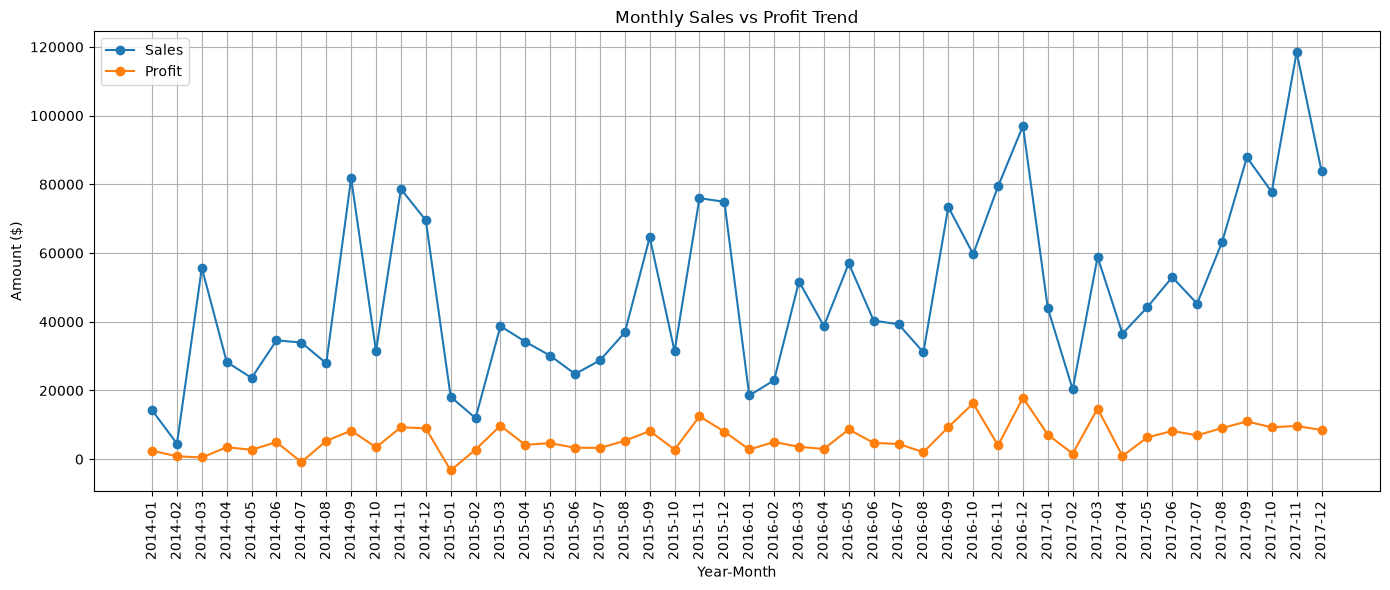

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["Year-Month"],
    monthly_summary["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_summary["Year-Month"],
    monthly_summary["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales vs Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Amount ($)")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [16]:
# PROJECT 6 — EDA #11: Top & Bottom Products by Profit

product_performance = (
    df_clean.groupby(["Product ID", "Product Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

product_performance["Profit Margin"] = (
    product_performance["Profit"]
    / product_performance["Sales"]
) * 100

print("===== TOP 10 PRODUCTS BY PROFIT =====")
display(
    product_performance
    .sort_values("Profit", ascending=False)
    .head(10)
)

print("===== BOTTOM 10 PRODUCTS BY PROFIT =====")
display(
    product_performance
    .sort_values("Profit", ascending=True)
    .head(10)
)

===== TOP 10 PRODUCTS BY PROFIT =====


,Product ID,Product Name,Sales,Profit,Quantity,Orders,Profit Margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,40.909091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,28.240741
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,37.070064
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,39.337349
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,22.285714
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2,49.000000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2,26.000000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24,7,39.459459
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3,21.071429
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6,2,48.000000


===== BOTTOM 10 PRODUCTS BY PROFIT =====


,Product ID,Product Name,Sales,Profit,Quantity,Orders,Profit Margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3,-80.000000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4,-27.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,-48.000000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27,5,-29.000000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33,7,-20.266667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6,-10.454545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6,1,-8.000000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22,6,-7.800000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4,-18.424658
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15,3,-67.307692


In [17]:
# PROJECT 6 — EDA #12: Product Profitability vs Discount

product_discount = (
    df_clean.groupby(["Product ID", "Product Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

product_discount["Profit Margin"] = (
    product_discount["Profit"]
    / product_discount["Sales"]
) * 100

print("===== TOP 10 PRODUCTS =====")

display(
    product_discount
    .sort_values("Profit", ascending=False)
    .head(10)
)

print("===== BOTTOM 10 PRODUCTS =====")

display(
    product_discount
    .sort_values("Profit", ascending=True)
    .head(10)
)

===== TOP 10 PRODUCTS =====


,Product ID,Product Name,Sales,Profit,Quantity,Orders,Avg_Discount,Profit Margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,0.120000,40.909091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,0.240000,28.240741
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,0.200000,37.070064
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,0.150000,39.337349
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,0.166667,22.285714
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2,0.000000,49.000000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2,0.000000,26.000000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24,7,0.057143,39.459459
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3,0.333333,21.071429
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6,2,0.000000,48.000000


===== BOTTOM 10 PRODUCTS =====


,Product ID,Product Name,Sales,Profit,Quantity,Orders,Avg_Discount,Profit Margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3,0.533333,-80.000000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4,0.400000,-27.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,0.500000,-48.000000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27,5,0.280000,-29.000000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33,7,0.350000,-20.266667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6,0.450000,-10.454545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6,1,0.500000,-8.000000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22,6,0.100000,-7.800000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4,0.200000,-18.424658
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15,3,0.483333,-67.307692


In [18]:
# PROJECT 6 — EDA #13: Customer Segment Profitability

segment_performance = (
    df_clean.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

segment_performance["Profit Margin"] = (
    segment_performance["Profit"]
    / segment_performance["Sales"]
) * 100

segment_performance = segment_performance.sort_values(
    "Sales", ascending=False
)

display(segment_performance)

,Segment,Sales,Profit,Quantity,Orders,Customers,Profit Margin
0,Consumer,1.161401e+06,134119.2092,19521,2586,409,11.548050
1,Corporate,7.061464e+05,91979.1340,11608,1514,236,13.025506
2,Home Office,4.296531e+05,60298.6785,6744,909,148,14.034269


In [19]:
# PROJECT 6 — EDA #14: Segment × Category Profitability

segment_category = (
    df_clean.groupby(["Segment", "Category"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

segment_category["Profit Margin"] = (
    segment_category["Profit"]
    / segment_category["Sales"]
) * 100

display(
    segment_category.sort_values(
        ["Segment", "Profit Margin"]
    )
)

,Segment,Category,Sales,Profit,Orders,Profit Margin
0,Consumer,Furniture,391049.3120,6991.0786,917,1.787774
1,Consumer,Office Supplies,363952.1360,56330.3210,1922,15.477398
2,Consumer,Technology,406399.8970,70797.8096,809,17.420725
3,Corporate,Furniture,229019.7858,7584.8158,540,3.311860
4,Corporate,Office Supplies,230676.4620,40227.3202,1142,17.438849
5,Corporate,Technology,246450.1190,44166.9980,454,17.921273
6,Home Office,Furniture,121930.6975,3875.3784,307,3.178345
8,Home Office,Technology,183304.0170,30490.1405,281,16.633646
7,Home Office,Office Supplies,124418.4340,25933.1596,678,20.843503


In [20]:
# PROJECT 6 — EDA #15: Shipping Performance

shipping_performance = (
    df_clean.groupby("Ship Mode")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Shipping_Days=("Shipping Days", "mean")
    )
    .reset_index()
)

shipping_performance["Profit Margin"] = (
    shipping_performance["Profit"]
    / shipping_performance["Sales"]
) * 100

shipping_performance = shipping_performance.sort_values(
    "Avg_Shipping_Days"
)

display(shipping_performance)

,Ship Mode,Orders,Sales,Profit,Avg_Shipping_Days,Profit Margin
1,Same Day,264,1.283631e+05,15891.7589,0.044199,12.380315
0,First Class,787,3.514284e+05,48969.8399,2.182705,13.934513
2,Second Class,964,4.591936e+05,57446.6354,3.238046,12.510331
3,Standard Class,2994,1.358216e+06,164088.7875,5.006535,12.081202


In [21]:
# PROJECT 6 — EDA #16: Consolidated Profitability Matrix

profitability_matrix = (
    df_clean.groupby(["Region", "Category"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

profitability_matrix["Profit Margin"] = (
    profitability_matrix["Profit"]
    / profitability_matrix["Sales"]
) * 100

# Rank combinations by profit margin
profitability_matrix["Margin Rank"] = (
    profitability_matrix["Profit Margin"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

display(
    profitability_matrix.sort_values(
        "Profit Margin", ascending=False
    )
)

,Region,Category,Sales,Profit,Orders,Profit Margin,Margin Rank
10,West,Office Supplies,220853.2490,52609.8490,1169,23.821180,1
4,East,Office Supplies,205516.0550,41014.5791,1074,19.956873,2
2,Central,Technology,170416.3120,33697.4320,356,19.773595,3
5,East,Technology,264973.9810,47462.0351,443,17.911961,4
11,West,Technology,251991.8320,44303.6496,490,17.581383,5
7,South,Office Supplies,125651.3130,19986.3928,619,15.906235,6
8,South,Technology,148771.9080,19991.8314,255,13.437908,7
6,South,Furniture,117298.6840,6771.2061,278,5.772619,8
1,Central,Office Supplies,167026.4150,8879.9799,880,5.316512,9
9,West,Furniture,252612.7435,11504.9503,595,4.554382,10


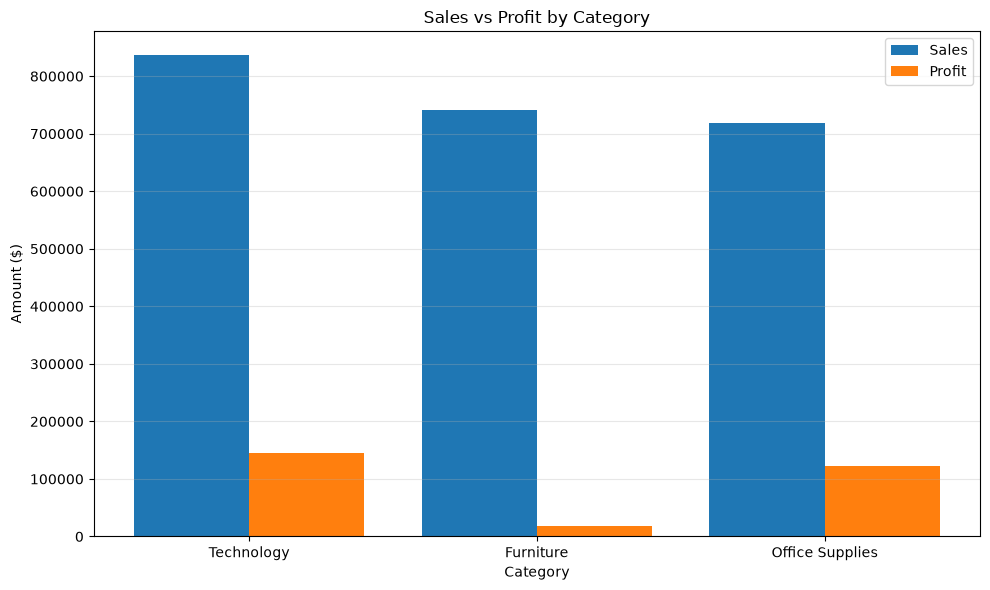

In [22]:
import matplotlib.pyplot as plt

category_chart = category_performance.sort_values(
    "Sales", ascending=False
)

plt.figure(figsize=(10, 6))

x = range(len(category_chart))

plt.bar(
    [i - 0.2 for i in x],
    category_chart["Sales"],
    width=0.4,
    label="Sales"
)

plt.bar(
    [i + 0.2 for i in x],
    category_chart["Profit"],
    width=0.4,
    label="Profit"
)

plt.xticks(x, category_chart["Category"])
plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

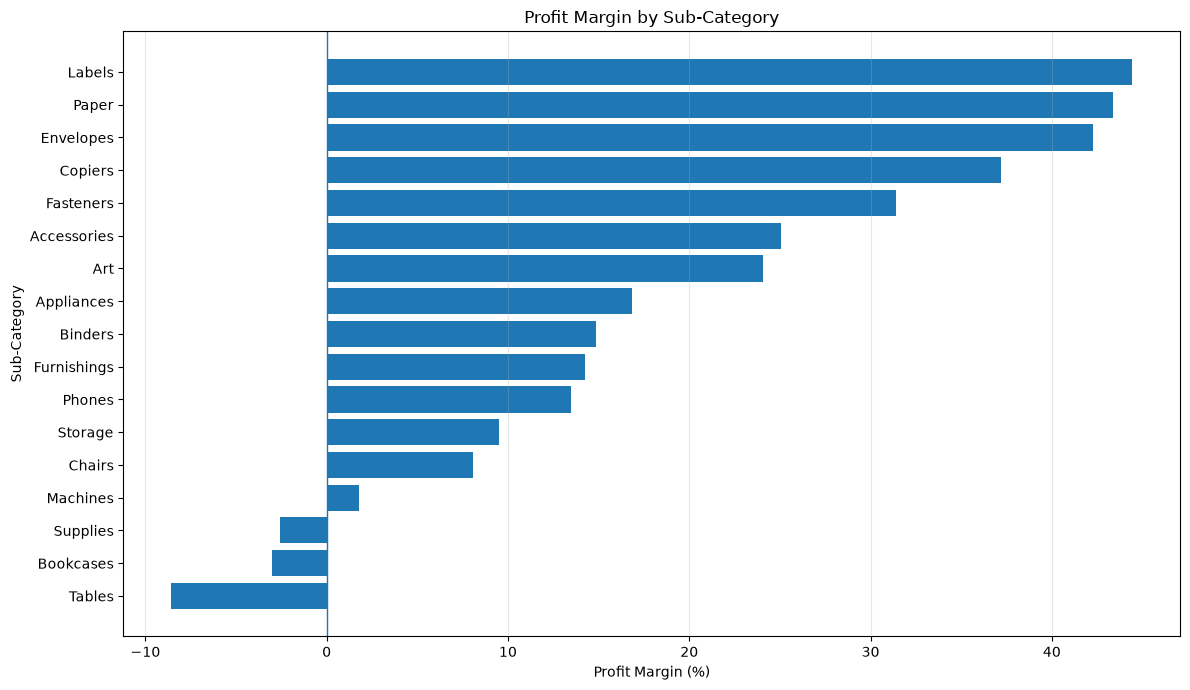

In [23]:
# PROJECT 6 — CHART 2: Profit Margin by Sub-Category

subcategory_chart = subcategory_performance.sort_values(
    "Profit Margin",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    subcategory_chart["Sub-Category"],
    subcategory_chart["Profit Margin"]
)

plt.axvline(0, linewidth=1)

plt.title("Profit Margin by Sub-Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-Category")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

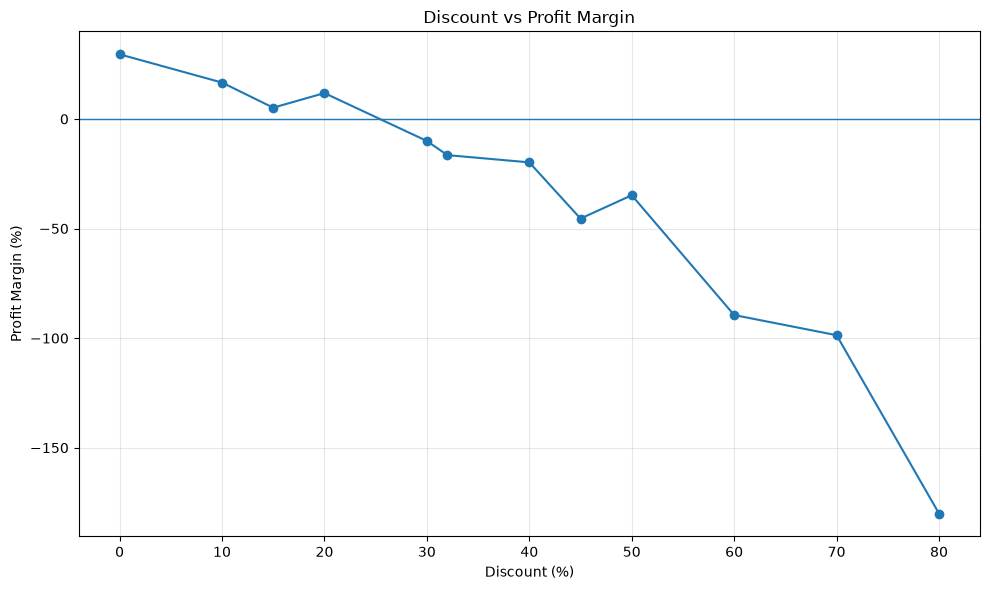

In [24]:
# PROJECT 6 — CHART 3: Discount vs Profit Margin

plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis["Discount"] * 100,
    discount_analysis["Profit Margin"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Discount vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

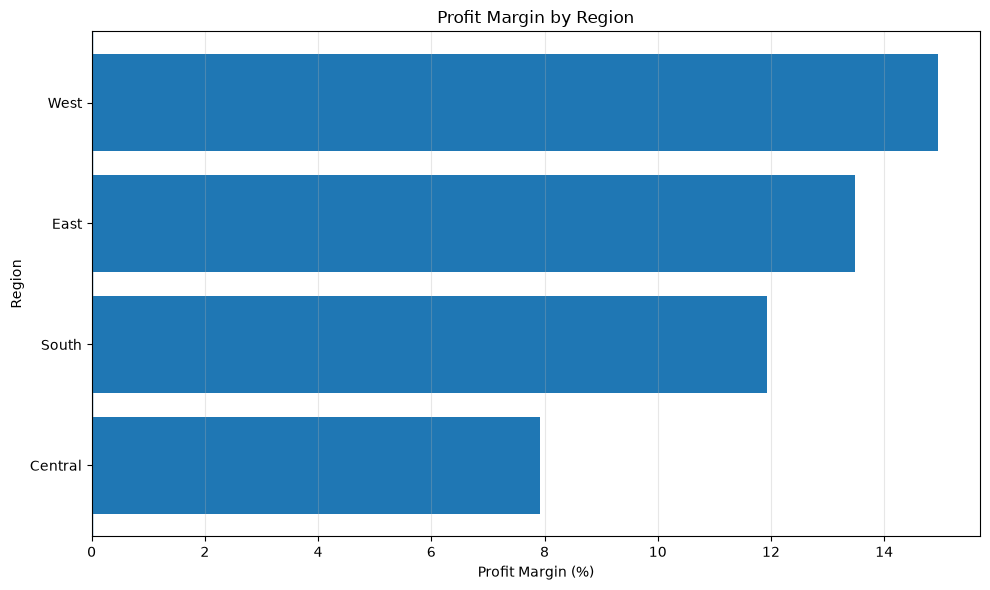

In [25]:
# PROJECT 6 — CHART 4: Regional Profitability

region_chart = regional_performance.sort_values(
    "Profit Margin",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    region_chart["Region"],
    region_chart["Profit Margin"]
)

plt.axvline(0, linewidth=1)

plt.title("Profit Margin by Region")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

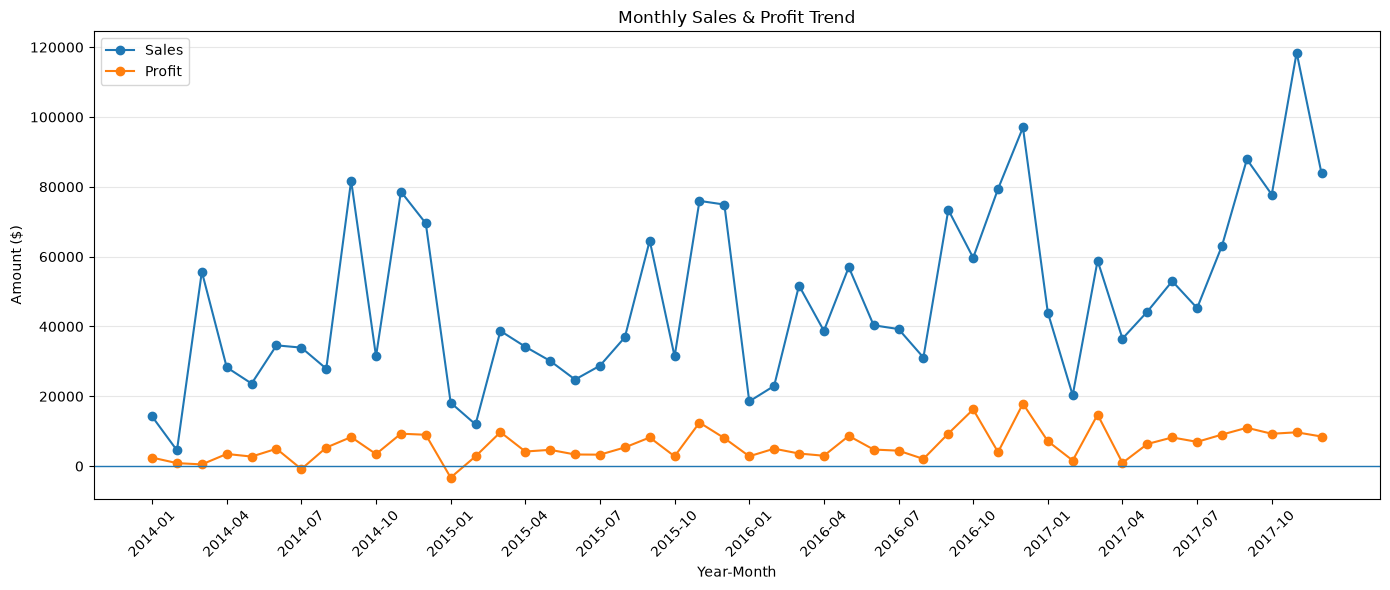

In [26]:
# PROJECT 6 — CHART 5: Monthly Sales & Profit Trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["Year-Month"],
    monthly_summary["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_summary["Year-Month"],
    monthly_summary["Profit"],
    marker="o",
    label="Profit"
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Sales & Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Amount ($)")

# Show every 3rd month to reduce crowding
plt.xticks(
    range(0, len(monthly_summary), 3),
    monthly_summary["Year-Month"].iloc[::3],
    rotation=45
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

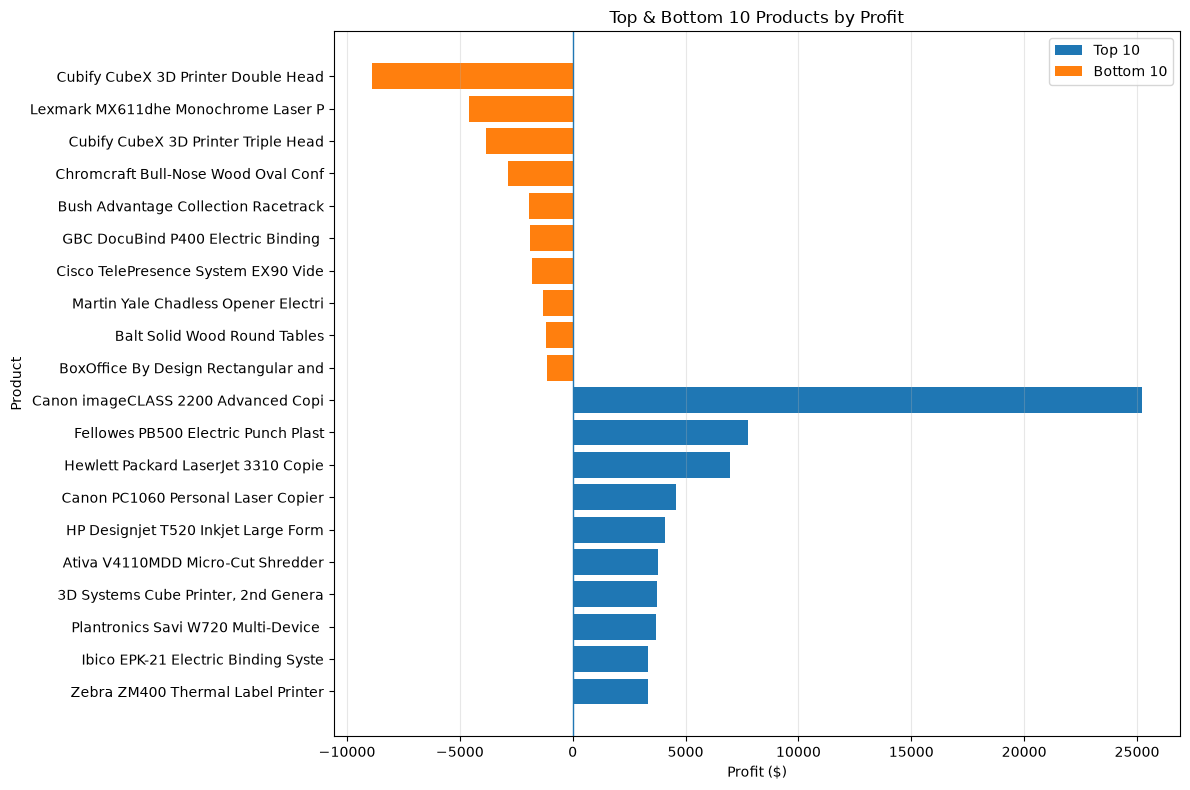

In [27]:
# PROJECT 6 — CHART 6: Top & Bottom Products by Profit

top_products = (
    product_discount
    .sort_values("Profit", ascending=False)
    .head(10)
    .sort_values("Profit")
)

bottom_products = (
    product_discount
    .sort_values("Profit", ascending=True)
    .head(10)
    .sort_values("Profit", ascending=False)
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_products["Product Name"].str[:35],
    top_products["Profit"],
    label="Top 10"
)

plt.barh(
    bottom_products["Product Name"].str[:35],
    bottom_products["Profit"],
    label="Bottom 10"
)

plt.axvline(0, linewidth=1)

plt.title("Top & Bottom 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.legend()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# PROJECT 6 — FINAL BUSINESS INSIGHTS

print("=" * 60)
print("PROJECT 6 — RETAIL SALES & PROFITABILITY ANALYSIS")
print("=" * 60)

print("\n1. OVERALL PERFORMANCE")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

print("\n2. CATEGORY INSIGHT")
for _, row in category_performance.iterrows():
    print(
        f"{row['Category']}: "
        f"Sales=${row['Sales']:,.0f}, "
        f"Profit=${row['Profit']:,.0f}, "
        f"Margin={row['Profit Margin']:.2f}%"
    )

print("\n3. LOSS-MAKING SUB-CATEGORIES")
loss_subcategories = subcategory_performance[
    subcategory_performance["Profit"] < 0
]

display(
    loss_subcategories[
        ["Category", "Sub-Category", "Sales", "Profit", "Profit Margin"]
    ].sort_values("Profit")
)

print("\n4. REGIONAL PERFORMANCE")
display(
    regional_performance[
        ["Region", "Sales", "Profit", "Profit Margin"]
    ].sort_values("Profit Margin", ascending=False)
)

print("\n5. CUSTOMER SEGMENT PERFORMANCE")
display(
    segment_performance[
        ["Segment", "Sales", "Profit", "Profit Margin"]
    ]
)

PROJECT 6 — RETAIL SALES & PROFITABILITY ANALYSIS

1. OVERALL PERFORMANCE
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%
Total Orders: 5,009
Total Customers: 793

2. CATEGORY INSIGHT
Technology: Sales=$836,154, Profit=$145,455, Margin=17.40%
Furniture: Sales=$742,000, Profit=$18,451, Margin=2.49%
Office Supplies: Sales=$719,047, Profit=$122,491, Margin=17.04%

3. LOSS-MAKING SUB-CATEGORIES


,Category,Sub-Category,Sales,Profit,Profit Margin
3,Furniture,Tables,206965.5320,-17725.4811,-8.564460
0,Furniture,Bookcases,114879.9963,-3472.5560,-3.022768
12,Office Supplies,Supplies,46673.5380,-1189.0995,-2.547695



4. REGIONAL PERFORMANCE


,Region,Sales,Profit,Profit Margin
3,West,725457.8245,108418.4489,14.944831
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
0,Central,501239.8908,39706.3625,7.921629



5. CUSTOMER SEGMENT PERFORMANCE


,Segment,Sales,Profit,Profit Margin
0,Consumer,1.161401e+06,134119.2092,11.548050
1,Corporate,7.061464e+05,91979.1340,13.025506
2,Home Office,4.296531e+05,60298.6785,14.034269


In [29]:
plt.savefig(
    "visualizations/category_performance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

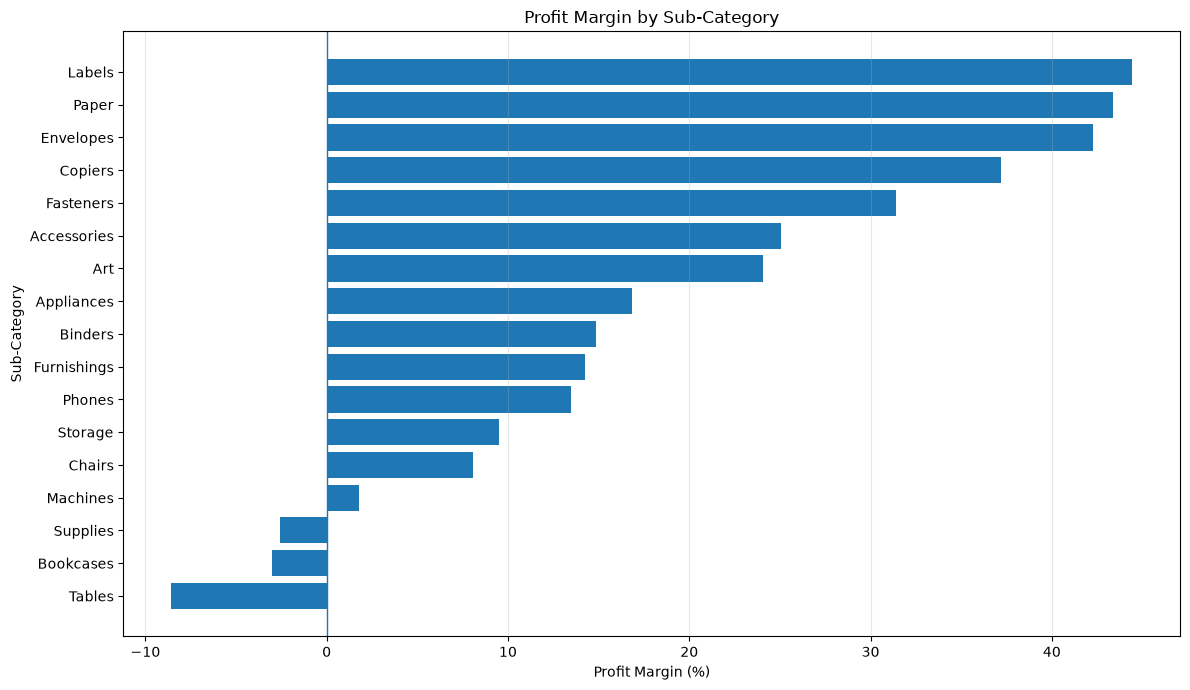

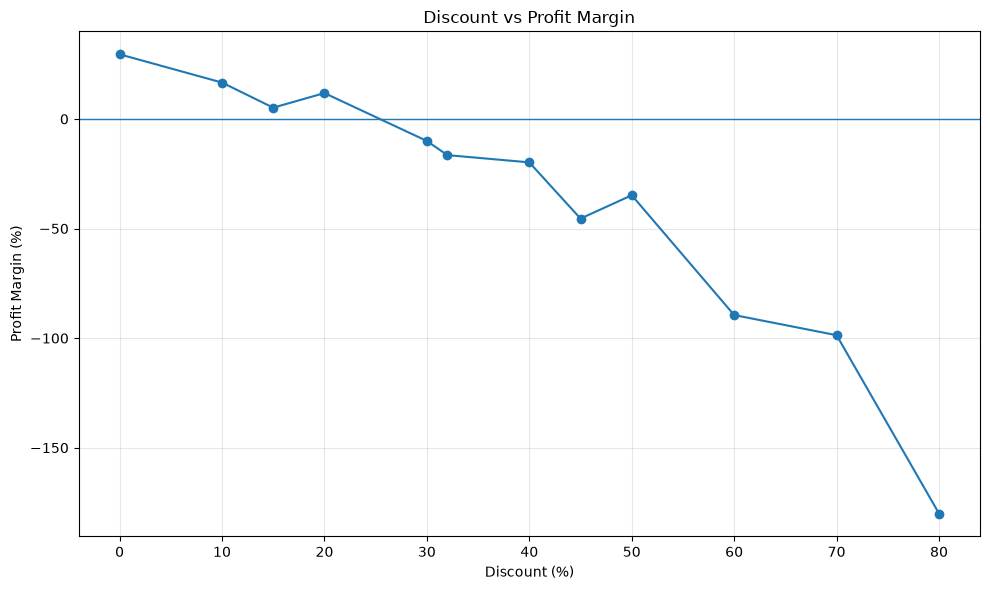

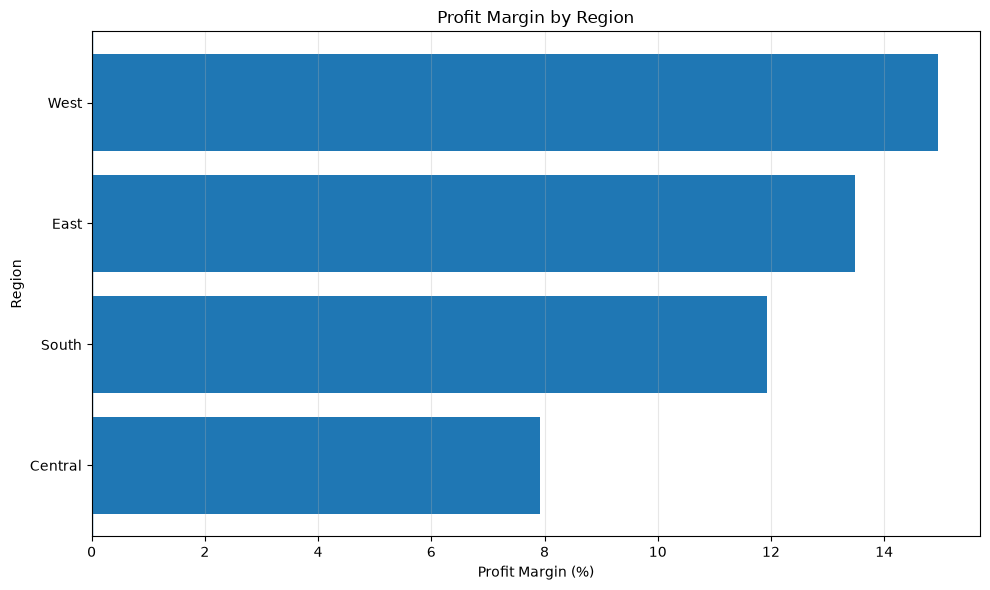

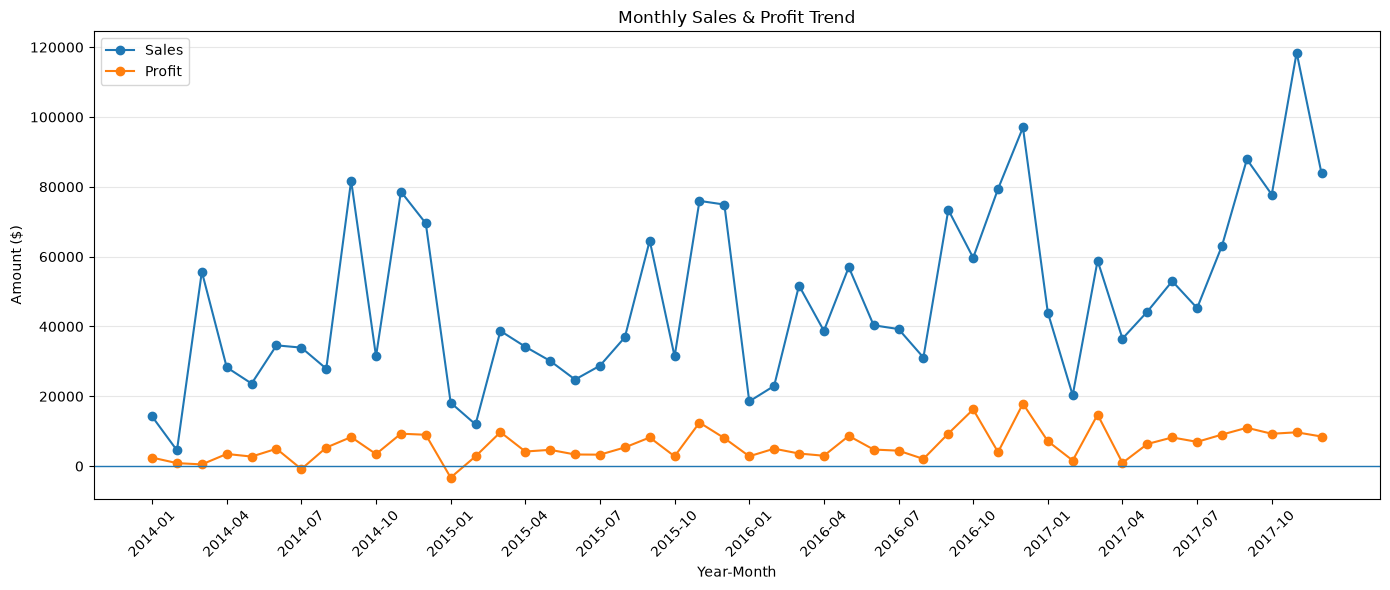

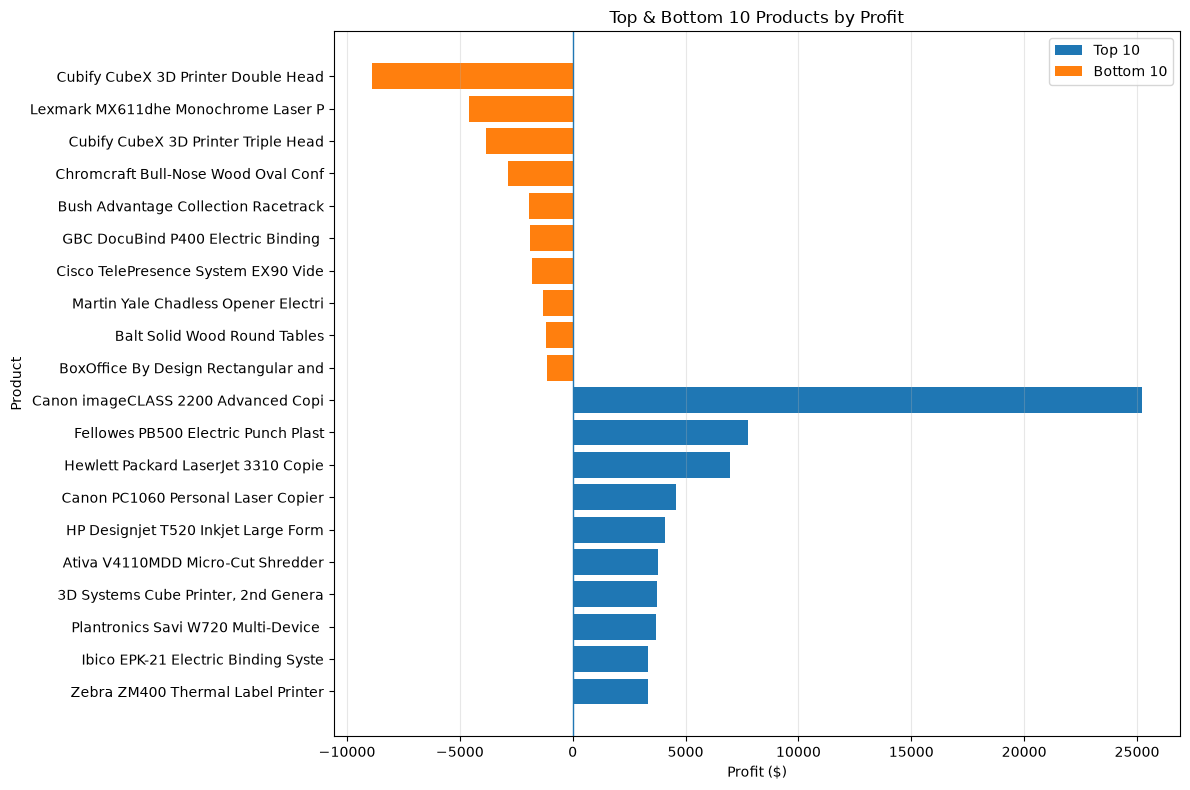

===== ALL VISUALIZATIONS EXPORTED =====
1. category_performance.png
2. subcategory_margin.png
3. discount_profit.png
4. regional_profitability.png
5. monthly_trend.png


In [30]:
# PROJECT 6 — EXPORT REMAINING VISUALIZATIONS

import matplotlib.pyplot as plt

# 2. Profit Margin by Sub-Category
subcategory_chart = subcategory_performance.sort_values(
    "Profit Margin", ascending=True
)

plt.figure(figsize=(12, 7))
plt.barh(
    subcategory_chart["Sub-Category"],
    subcategory_chart["Profit Margin"]
)
plt.axvline(0, linewidth=1)
plt.title("Profit Margin by Sub-Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "visualizations/subcategory_margin.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# 3. Discount vs Profit Margin
plt.figure(figsize=(10, 6))
plt.plot(
    discount_analysis["Discount"] * 100,
    discount_analysis["Profit Margin"],
    marker="o"
)
plt.axhline(0, linewidth=1)
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "visualizations/discount_profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# 4. Profit Margin by Region
region_chart = regional_performance.sort_values(
    "Profit Margin", ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    region_chart["Region"],
    region_chart["Profit Margin"]
)
plt.axvline(0, linewidth=1)
plt.title("Profit Margin by Region")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "visualizations/regional_profitability.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# 5. Monthly Sales & Profit Trend
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["Year-Month"],
    monthly_summary["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_summary["Year-Month"],
    monthly_summary["Profit"],
    marker="o",
    label="Profit"
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Sales & Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Amount ($)")

plt.xticks(
    range(0, len(monthly_summary), 3),
    monthly_summary["Year-Month"].iloc[::3],
    rotation=45
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "visualizations/monthly_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# 6. Top & Bottom 10 Products by Profit
top_products = (
    product_discount
    .sort_values("Profit", ascending=False)
    .head(10)
    .sort_values("Profit")
)

bottom_products = (
    product_discount
    .sort_values("Profit", ascending=True)
    .head(10)
    .sort_values("Profit", ascending=False)
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_products["Product Name"].str[:35],
    top_products["Profit"],
    label="Top 10"
)

plt.barh(
    bottom_products["Product Name"].str[:35],
    bottom_products["Profit"],
    label="Bottom 10"
)

plt.axvline(0, linewidth=1)

plt.title("Top & Bottom 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "visualizations/top_bottom_products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("===== ALL VISUALIZATIONS EXPORTED =====")
print("1. category_performance.png")
print("2. subcategory_margin.png")
print("3. discount_profit.png")
print("4. regional_profitability.png")
print("5. monthly_trend.png")
